# **Marketing Campaign Analysis**

**Note: In this part to avoid long notebook, some of the visualizations are removed. Only necessary visuals related to outliers are still there (To get more information about EDA please see milestone project).**

## **Milestone Summary / Executive Summary**
- In the milestone part we studied the main problem, objective, and the goal. 
- We analized differen models including: k_mean, k_medoid, Hierarchial Agglomerative clustering, DBSCAN, and Gaussian mixture. 
- The best model was choosed based on Silhouette scoring measure and it was k_mean clustering with 3 clusters (3 clusters was choosed based on the elbow method. Also the score for 4 and 5 clusters was lower).


### **Capestone Objective:**


- In This part two extra models will be analized.
    - UMAP dimension reduction method + k_mean
    - HdDBSCAN

- At the end there will be final conclusion, summary, and recommendation

## **Import the necessary libraries and load the data**

In [76]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# To compute distances
from scipy.spatial.distance import cdist, pdist

# To perform K-Means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To import K-Medoids
from sklearn_extra.cluster import KMedoids

# To import DBSCAN and Gaussian Mixture
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# To perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

import umap
import hdbscan
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

## **Data Overview**

- Reading the dataset
- Understanding the shape of the dataset
- Checking the data types
- Checking for missing values
- Checking for duplicated values
- Drop the column which has no null values

In [2]:
data = pd.read_csv('marketing_campaign.csv')

In [3]:
data.shape

(2240, 27)

In [4]:
df = data.copy()

In [5]:
df.duplicated().sum()

0

In [6]:
df.drop('ID', axis=1, inplace=True)

In [7]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [8]:
# Changing '2nd Cycle' to 'Master' for consistency
df['Education'].replace("2n Cycle", "Master", inplace=True)
df['Education'].value_counts()

Education
Graduation    1127
Master         573
PhD            486
Basic           54
Name: count, dtype: int64

In [9]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
df['Marital_Status'].replace("Absurd", "Single", inplace=True)
df['Marital_Status'].replace("YOLO", "Single", inplace=True)
df['Marital_Status'].replace("Alone", "Single", inplace=True)
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

In [11]:
df['Income'].isnull().sum()

24

In [12]:
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [13]:
# Filling missing values in 'Income' with the mean
df['Income'].fillna(df['Income'].mean(), inplace=True)
df['Income'].isnull().sum()

0

In [14]:
# Function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize = (12, 7), kde = False, bins = None):
    
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12, 7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 2,      # Number of rows of the subplot grid = 2
        sharex = True,  # X-axis will be shared among all subplots
        gridspec_kw = {"height_ratios": (0.25, 0.75)},
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "violet"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins, palette = "winter"
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

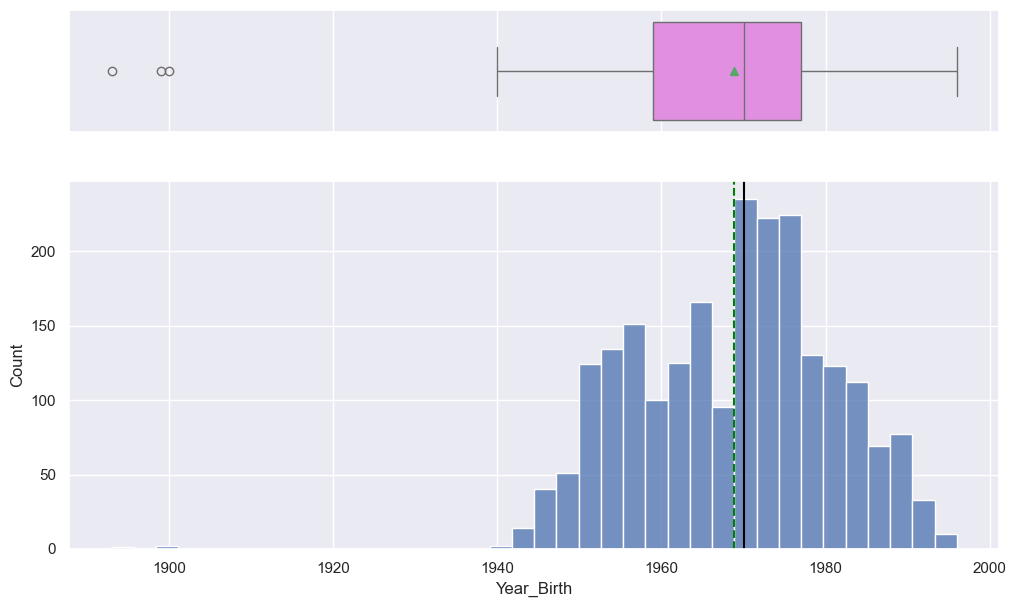

In [15]:
histogram_boxplot(df, 'Year_Birth')

In [16]:
df[df['Year_Birth'] < 1930]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
192,1900,Master,Divorced,36640.0,1,0,26-09-2013,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,0
239,1893,Master,Single,60182.0,0,1,17-05-2014,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,0
339,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,0


- In the year distribution there are three people who are 125, 126, and 132. Probably these are wrong values. 
- We will drop this values since we have not enough information to correct the year.

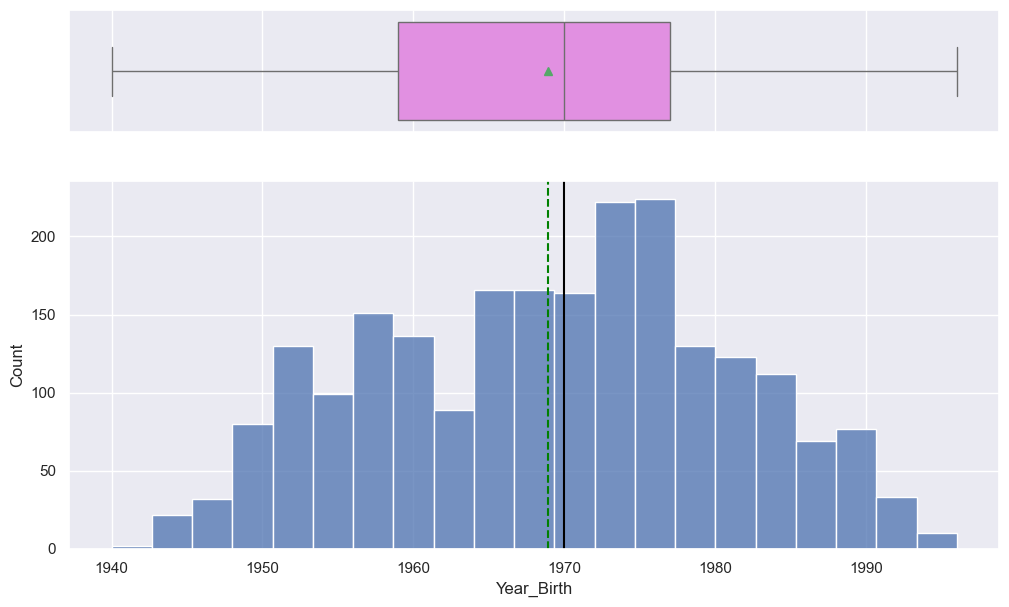

In [17]:
# drop years less than 1930 with median of 'Year_Birth'
df = df[df['Year_Birth'] >= 1930]
histogram_boxplot(df, 'Year_Birth')

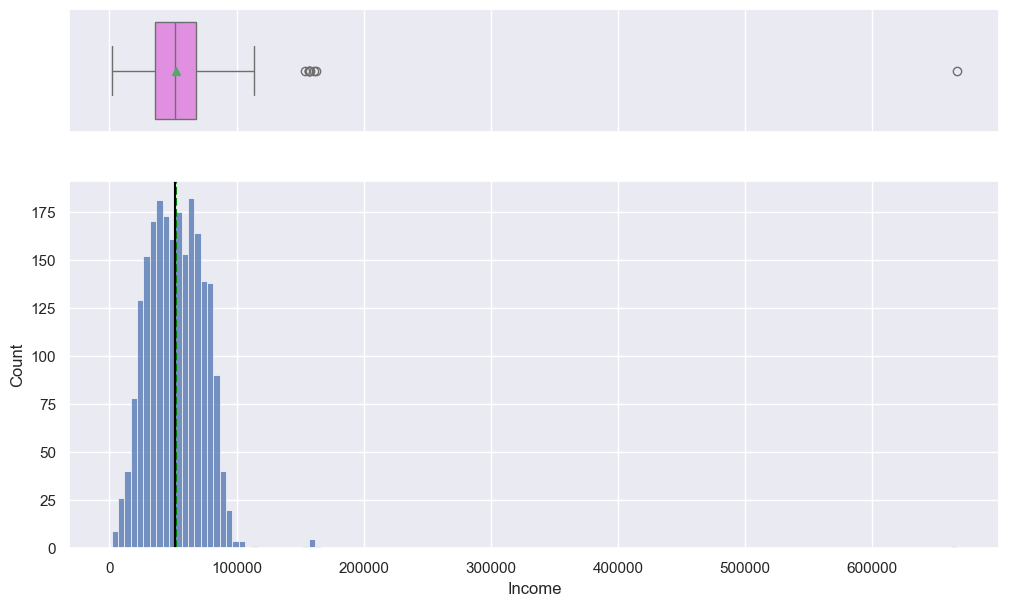

In [18]:
histogram_boxplot(df, 'Income')

In [19]:
df[df['Income'] > 200000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
2233,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,0


In [20]:
df[df['Income'] > 150000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
164,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,0
617,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,0
655,1975,Graduation,Divorced,153924.0,0,0,07-02-2014,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
687,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,0
1300,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,0
1653,1977,Graduation,Together,157146.0,0,0,29-04-2013,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,0
2132,1949,PhD,Married,156924.0,0,0,29-08-2013,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2233,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,0


In [21]:
df['Income'].quantile(0.99)

94440.31999999999

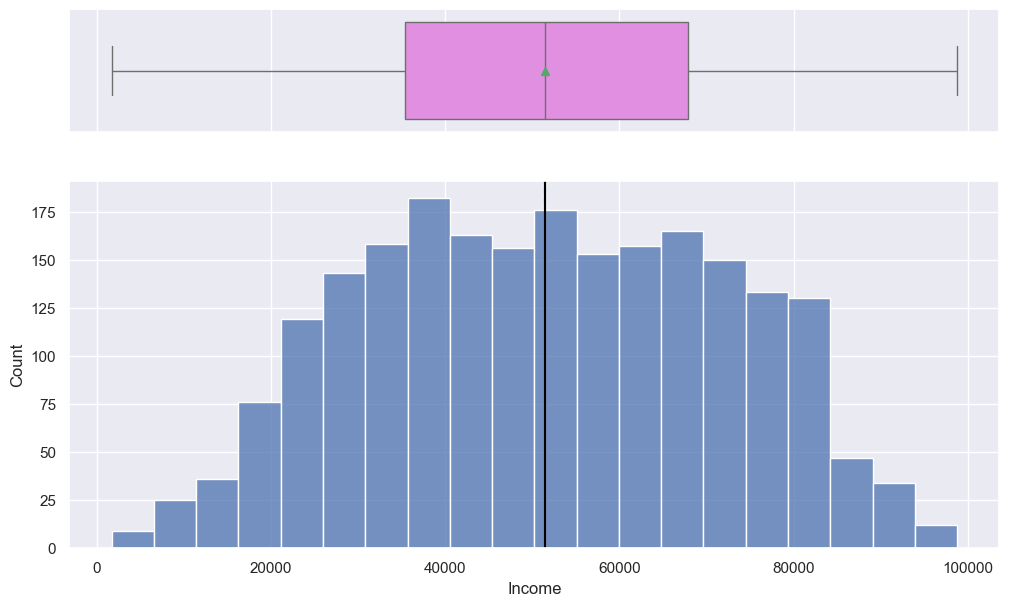

In [22]:
# Droping outliers in 'Income' column (salariy above 200K)
df = df[df['Income'] < 100000].reset_index(drop=True)
histogram_boxplot(df, 'Income')

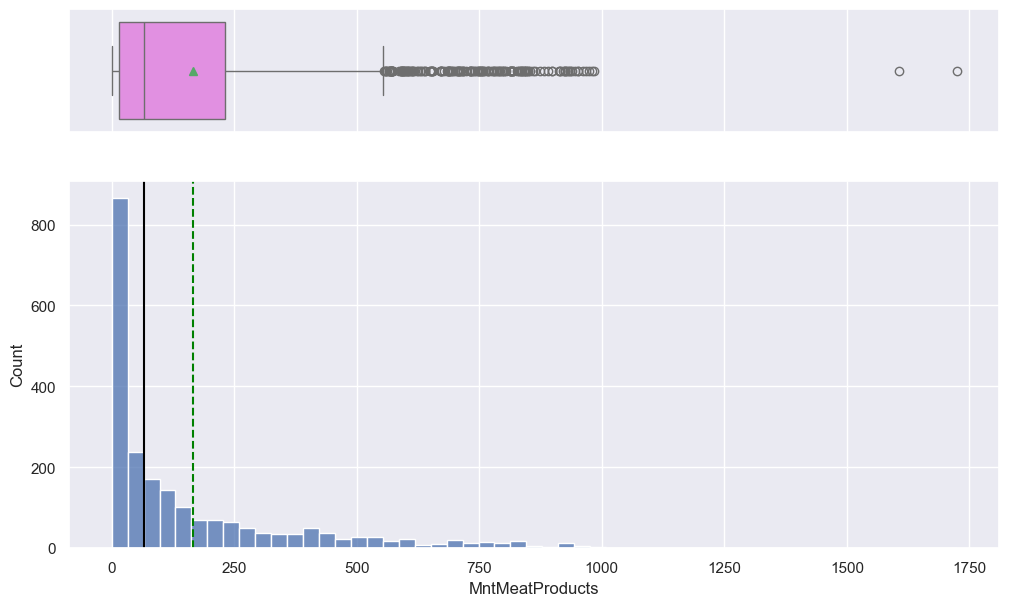

In [23]:
histogram_boxplot(df, 'MntMeatProducts')

In [24]:
df['MntMeatProducts'].quantile(0.99)

898.77

In [25]:
df[df['MntMeatProducts'] > 1000 ]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
21,1979,Graduation,Married,2447.000000,1,0,06-01-2013,42,1,1,1725,1,1,1,15,0,28,0,1,0,0,0,0,0,0,0
2213,1978,Master,Together,52247.251354,0,0,12-08-2012,53,32,2,1607,12,4,22,0,0,0,1,0,0,1,0,0,0,0,0


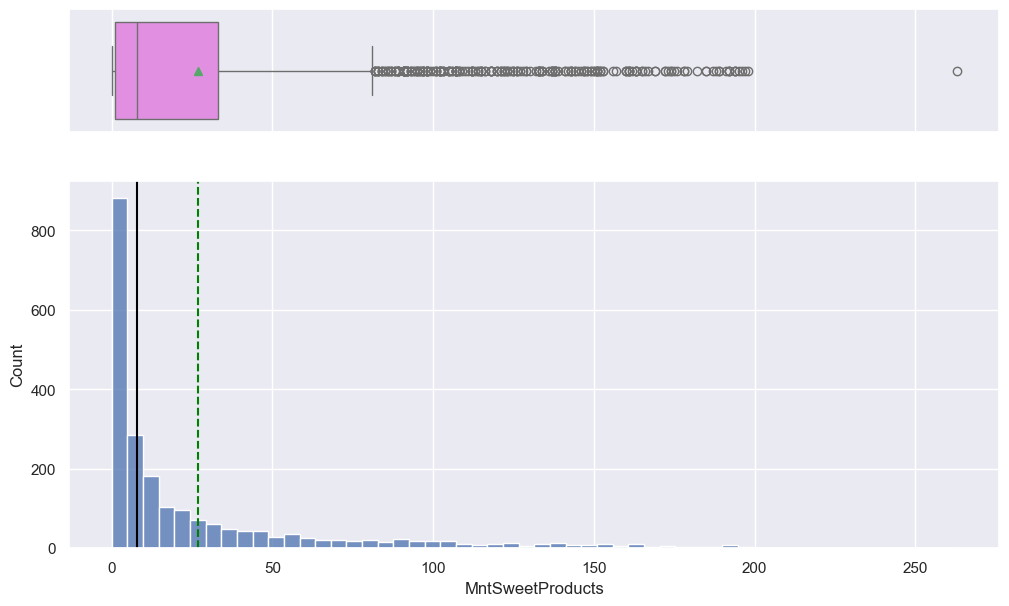

In [26]:
histogram_boxplot(df, 'MntSweetProducts')

In [27]:
df['MntSweetProducts'].quantile(0.99)

175.76999999999998

In [28]:
df[df['MntSweetProducts'] > 200]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
27,1986,Graduation,Single,52247.251354,1,0,20-02-2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,0


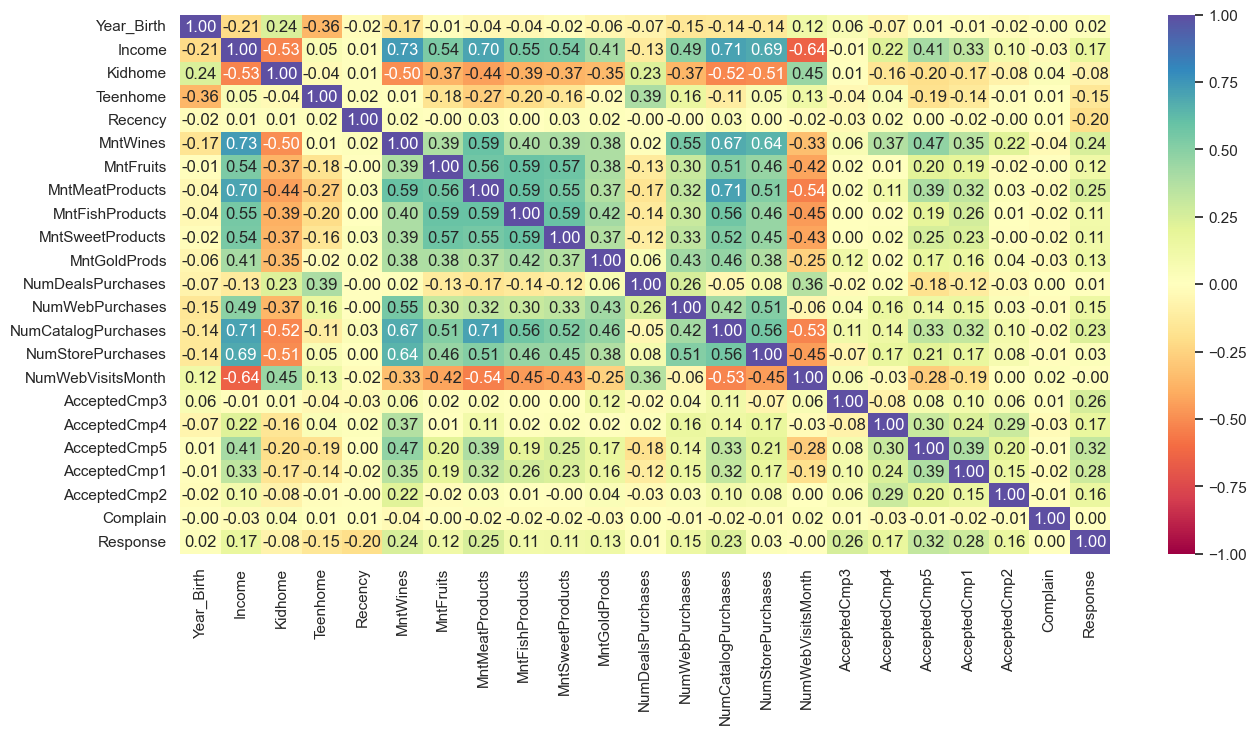

In [29]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15, 7))

sns.heatmap(
    df[numeric_cols].corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)

plt.show()

### **Feature Engineering and Data Processing**

In this section, we will first prepare our dataset for analysis.
- Imputing missing values

In [30]:
# extracting the age of each customer 
df['Age'] = 2016 - df['Year_Birth']


In [31]:
# Creating children column including both Kidhome and Teenhome
df['Children'] = df['Kidhome'] + df['Teenhome']

In [32]:
# Finding the total number of family members
# For this first we have to combine marital status 
df['Parent_Status'] = df['Marital_Status'].replace({
    'Single': 'Single',
    'Married': 'Relation',
    'Together': 'Relation',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Alone': 'Single'
})

In [33]:
df['Family_Size'] = df['Children'] + df['Parent_Status'].replace({
    'Single': 1,
    'Relation': 2
})

In [34]:
# Finding the amount spent by the customers on all products
df['Total_Spent'] = (
    df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
    df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
)

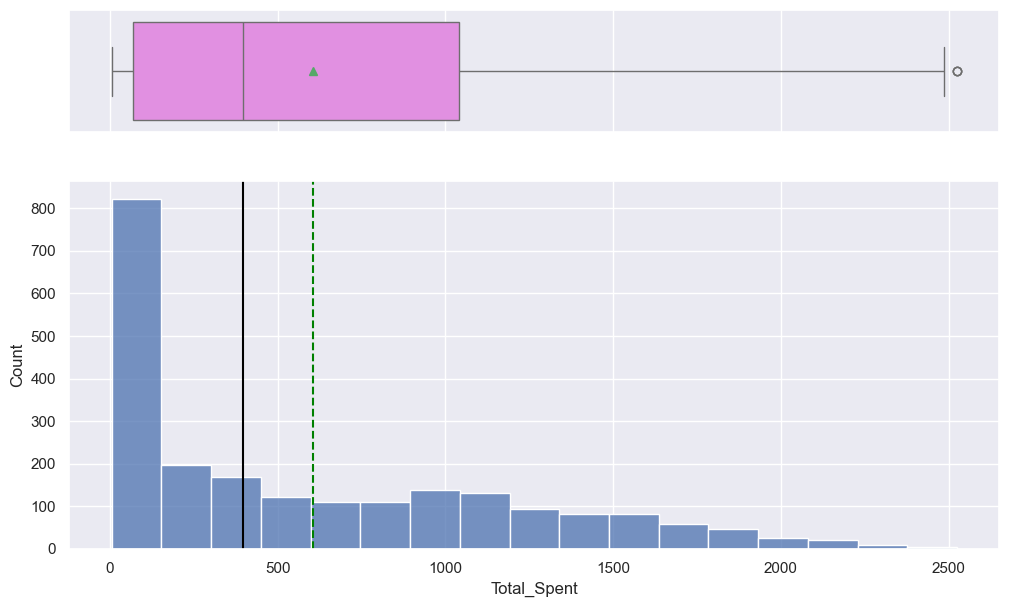

In [35]:
histogram_boxplot(df, 'Total_Spent')

In [36]:
# Number of total purchases made by the customers
df['Num_Total_Purchases'] = (
    df['NumDealsPurchases'] + df['NumStorePurchases'] +
    df['NumWebPurchases'] + df['NumCatalogPurchases']
)


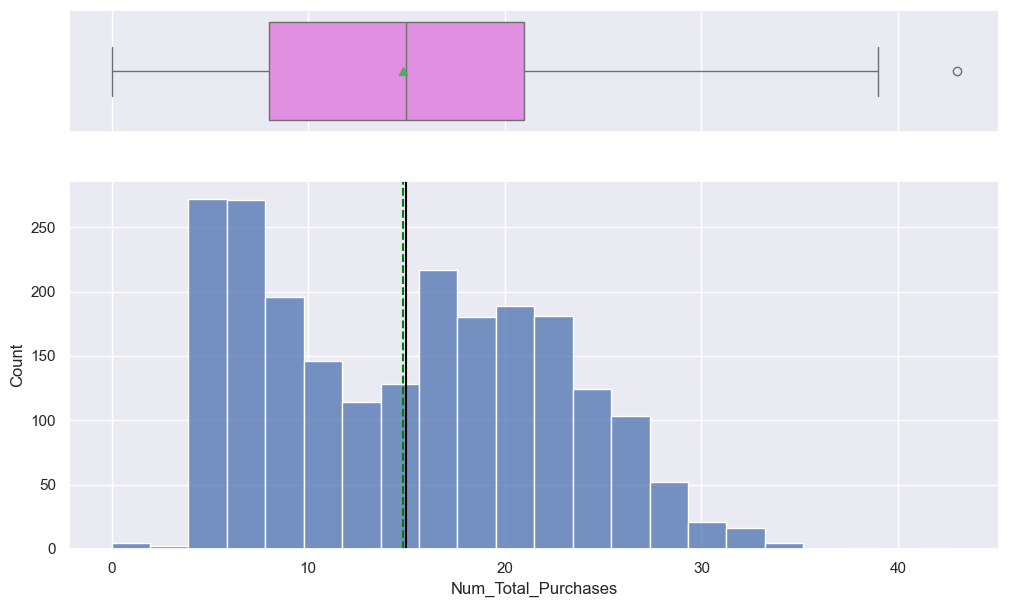

In [37]:
histogram_boxplot(df, 'Num_Total_Purchases')

In [38]:
# Amount spent per purchase if total purchases is 0 then it will be 0
df['Spent_Per_Purchase'] = np.where(
    df['Num_Total_Purchases'] == 0,
    0,
    df['Total_Spent'] / df['Num_Total_Purchases']
)

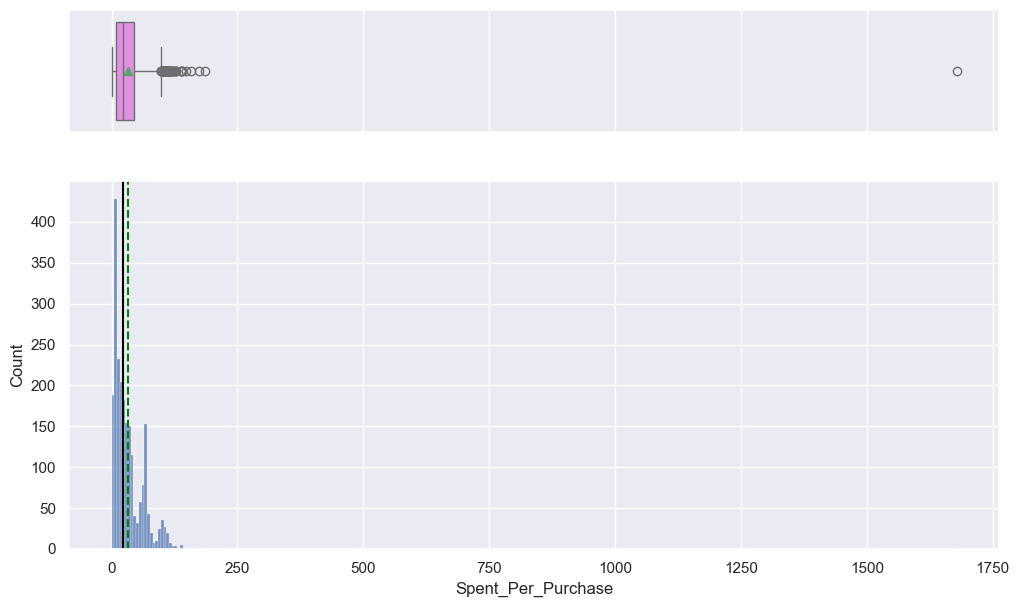

In [39]:
histogram_boxplot(df, 'Spent_Per_Purchase')

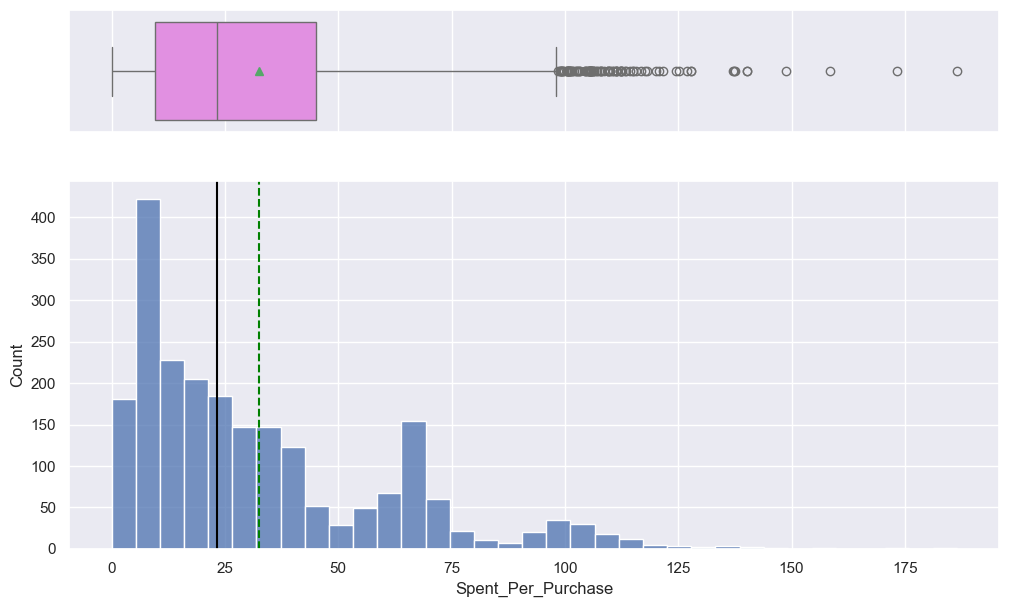

In [40]:
# dropping outliers in 'Spent_Per_Purchase' column
df = df[df['Spent_Per_Purchase'] < 250].reset_index(drop=True)
histogram_boxplot(df, 'Spent_Per_Purchase')

In [41]:
# We can convert the date of enrollment into days since enrollment
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')


In [42]:
df['Dt_Customer'].min(), df['Dt_Customer'].max()

(Timestamp('2012-07-30 00:00:00'), Timestamp('2014-06-29 00:00:00'))

In [43]:
df['Days_Since_Enrolled'] = (pd.to_datetime('01-01-2016') - pd.to_datetime(df['Dt_Customer'])).dt.days

In [44]:
# Finding the total amount of accepted campaigns
df['Total_Accepted_Campaigns'] = (
    df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] +
    df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response']
)   

## **Data Preparation for Segmentation**

In [45]:
df.head(3)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Children,Parent_Status,Family_Size,Total_Spent,Num_Total_Purchases,Spent_Per_Purchase,Days_Since_Enrolled,Total_Accepted_Campaigns
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,59,0,Single,1,1617,25,64.680000,1214,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,62,2,Single,3,27,6,4.500000,664,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,51,0,Relation,2,776,21,36.952381,863,0


In [46]:
# Since we created new features, we don't need the original columns anymore
df.drop(columns=[
    "Year_Birth",
    "Kidhome",
    "Teenhome",
    "Dt_Customer",
], inplace=True)

In [47]:
# Dropping demographic columns that are not needed for clustering
df_model = df.drop(
    columns=[
        #"Year_Birth", # we created 'Age' column
        #"Dt_Customer", # we created 'Days_Since_Enrolled' column
        "Complain", # Most of the customers have no compaint
        "Response", # we created 'Total_Accepted_Campaigns' column
        "AcceptedCmp1", 
        "AcceptedCmp2",
        "AcceptedCmp3",
        "AcceptedCmp4",
        "AcceptedCmp5",
        "Marital_Status", # we created Family_Size and Parent_Status
        "Parent_Status", 
        "Children",
        "Education",
        #"Kidhome",
        #"Teenhome",
        "Recency", #It has no serious correlation with other columns
        "Income",
        "Age",
        "Family_Size",
        "Days_Since_Enrolled"
    ],
    axis=1,
)

In [48]:
df_model.head(3)

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Spent,Num_Total_Purchases,Spent_Per_Purchase,Total_Accepted_Campaigns
0,635,88,546,172,88,88,3,8,10,4,7,1617,25,64.680000,1
1,11,1,6,2,1,6,2,1,1,2,5,27,6,4.500000,0
2,426,49,127,111,21,42,1,8,2,10,4,776,21,36.952381,0


- Now we have only behavorial features in the table. 

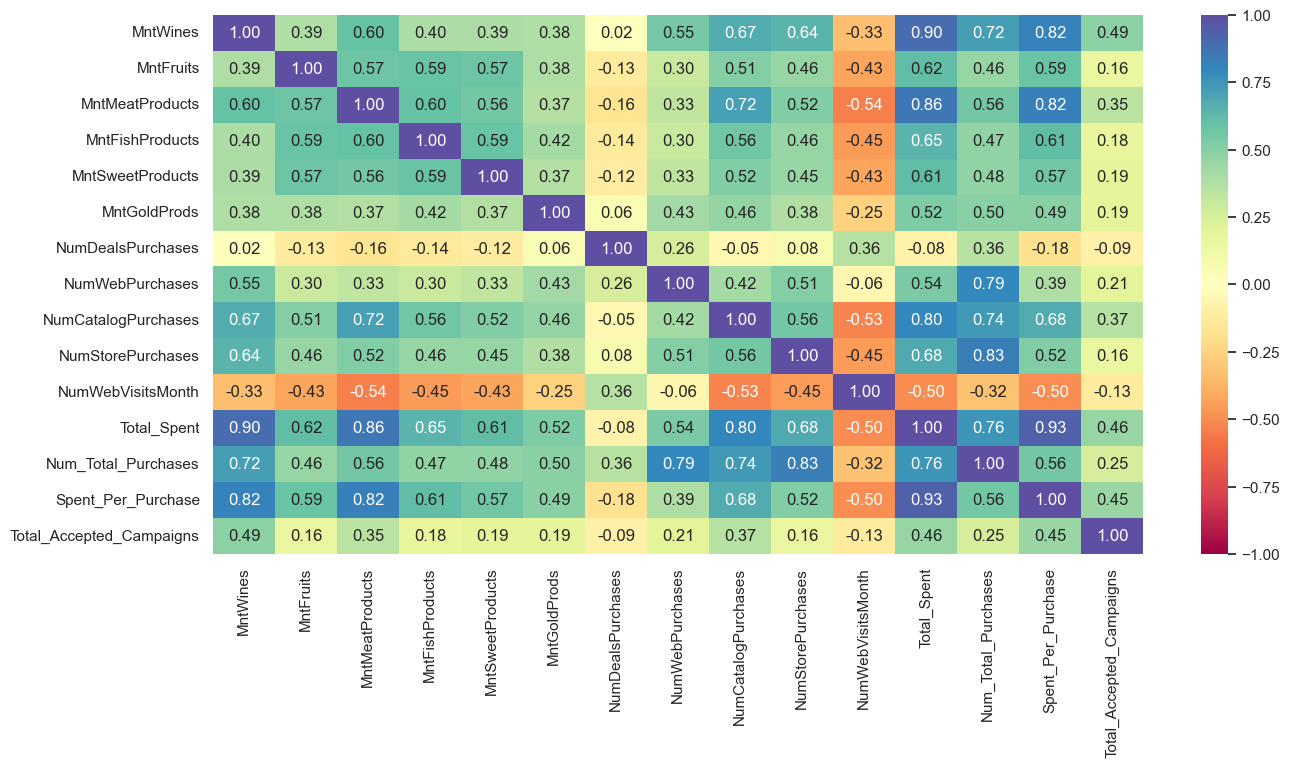

In [49]:
# correlation of new table

plt.figure(figsize = (15, 7))

sns.heatmap(
    df_model.corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)

plt.show()


- Family size have some positive correlation with Deals purchases and visiting website 
    - However family size have in general negative correlation with purchasing products. Family with more members seems to buy less. 
    - There are also negative correlation between family size and total spend  and spending per purchase. 
- Total spend has very positive correlation with income, spending per purchase, number of total purchase, and purchasing products specially wines and meat. 

- Number of total purchases has positive relation with website purchases, catalog purchases, store purchases. 

- Total accepted campaigns have some positive relation with income, wine purchases, meat purchases, total spent money, and total number of purchase. 
    - However it has some negative relation with family size.

## **Applying PCA to the data to visualize the data distributed in 2 dimensions**

## **Scaling**

In [50]:
# Scaling the data before clustering
scaler = StandardScaler()
df_model_scaled= scaler.fit_transform(df_model)

In [51]:
df_scaled = pd.DataFrame (df_model_scaled, columns=df_model.columns)
df_scaled.head(2)

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Total_Spent,Num_Total_Purchases,Spent_Per_Purchase,Total_Accepted_Campaigns
0,0.982073,1.560167,1.754729,2.460286,1.495935,0.848374,0.356031,1.432975,2.644967,-0.559058,0.687305,1.687249,1.336028,1.129063,0.636098
1,-0.872690,-0.637775,-0.730015,-0.651196,-0.634705,-0.731233,-0.171959,-1.130074,-0.584291,-1.178284,-0.142388,-0.960922,-1.163964,-0.981799,-0.503343


In [52]:
# Defining PCA
n = df_model.shape[1]

pca = PCA (n_components=n, random_state=1)

# Applying PCA to the scaled data
data_pca = pd.DataFrame(pca.fit_transform(df_scaled))

# The percantage of variance explained by each component is stored
exp_var = (pca.explained_variance_ratio_)

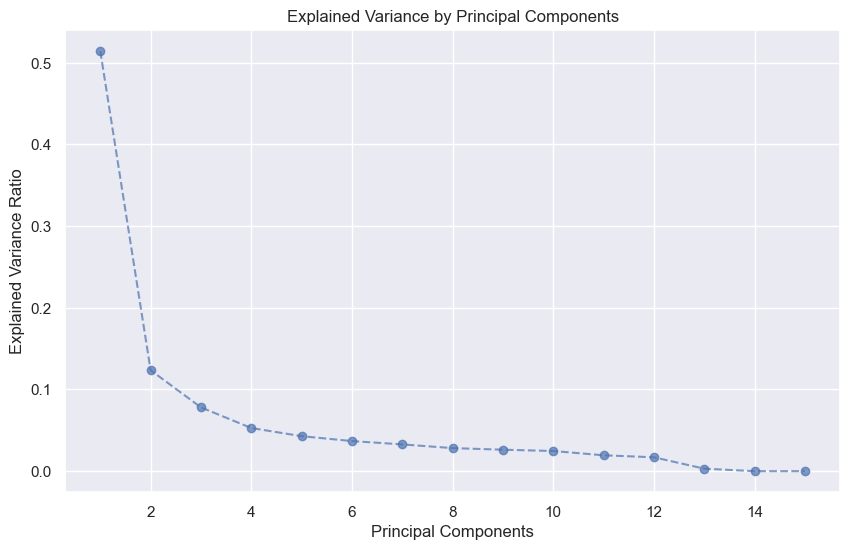

In [53]:
# Visualize the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, n + 1), exp_var, alpha=0.7, label='Individual explained variance', marker= 'o', linestyle='--')

plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')

plt.show()

In [54]:
# Finding the least number of components which explain more than 90% of the variance

sum_exp_var = 0
for ix, i in enumerate(exp_var):
    sum_exp_var += i
    if sum_exp_var >= 0.9:
        print(f"Number of components explaining more than 90% of variance: {ix + 1}")
        break

Number of components explaining more than 90% of variance: 8


In [55]:
data_pca_sum=round(data_pca.iloc[:, :8],2)
data_pca_sum.head(2)

,0,1,2,3,4,5,6,7
0,4.64,0.29,-0.18,1.85,-1.24,0.30,0.47,0.84
1,-2.89,-0.88,-0.05,-0.20,0.05,0.47,-0.14,0.08


## **K-Means** 
- Best Model from Milestone part. Number of clusters = 3 choosed from elbow method + Silhouette score

In [56]:
k_means_df = data_pca_sum.copy()

In [57]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init="auto")
kmeans.fit(k_means_df)

KMeans(n_clusters=3, n_init='auto', random_state=1)

In [58]:
score = silhouette_score(k_means_df, kmeans.labels_)
print(f"Silhouette Score for K-Means with 3 clusters: {score:.4f}")

Silhouette Score for K-Means with 3 clusters: 0.3711


### **Applying KMeans on the PCA data and visualize the clusters**

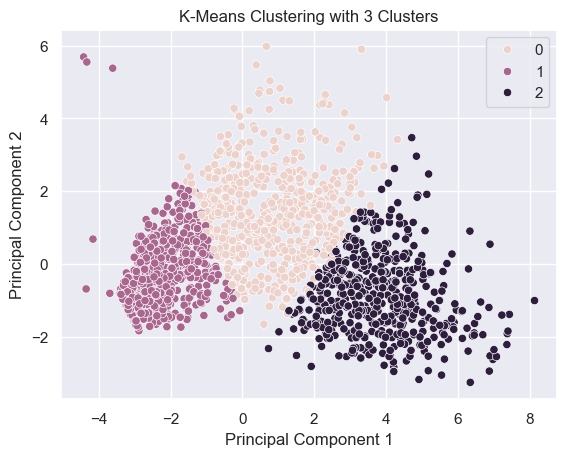

In [59]:
sns.scatterplot(data=data_pca_sum, x=0, y=1, hue=kmeans.labels_)
plt.title('K-Means Clustering with 3 Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### **Model Profile**

In [60]:
df_included_km = df.copy()

k_means_df["KM_segments"] = kmeans.labels_
df_included_km["KM_segments"] = kmeans.labels_

In [61]:
group_counts = k_means_df["KM_segments"].value_counts()
df_included_km['Count_per_Group'] = df_included_km['KM_segments'].map(group_counts)

In [62]:
df_included_km.head(3)

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Children,Parent_Status,Family_Size,Total_Spent,Num_Total_Purchases,Spent_Per_Purchase,Days_Since_Enrolled,Total_Accepted_Campaigns,KM_segments,Count_per_Group
0,Graduation,Single,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,59,0,Single,1,1617,25,64.680000,1214,1,2,549
1,Graduation,Single,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,62,2,Single,3,27,6,4.500000,664,0,1,1064
2,Graduation,Together,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,51,0,Relation,2,776,21,36.952381,863,0,0,610


In [63]:
mean = df_included_km.groupby("KM_segments").mean(numeric_only = True)
median = df_included_km.groupby("KM_segments").median(numeric_only = True)

km_cluster_profile = pd.concat([mean, median], axis=0)

km_cluster_profile.index = ["group_0 mean", "group_1 mean", "group_2 mean", 
                          "group_0 median", "group_1 median", "group_2 median"]
km_cluster_profile.T.style.highlight_max(color = "lightgreen", axis = 1)

,group_0 mean,group_1 mean,group_2 mean,group_0 median,group_1 median,group_2 median
Income,57769.561901,35284.472056,75993.201738,58300.500000,35178.000000,76542.000000
Recency,47.936066,49.167293,50.413479,49.000000,49.000000,53.000000
MntWines,450.655738,45.663534,644.153005,393.000000,23.000000,587.000000
MntFruits,24.306557,4.935150,69.697632,15.000000,2.000000,57.000000
MntMeatProducts,141.222951,23.433271,464.373406,124.000000,15.000000,428.000000
MntFishProducts,31.736066,7.184211,102.978142,19.000000,3.000000,94.000000
MntSweetProducts,24.490164,5.105263,71.885246,14.000000,2.000000,58.000000
MntGoldProds,62.057377,15.365602,79.267760,42.000000,10.000000,58.000000
NumDealsPurchases,3.708197,2.045113,1.333333,3.000000,2.000000,1.000000
NumWebPurchases,6.439344,2.155075,5.214936,6.000000,2.000000,5.000000


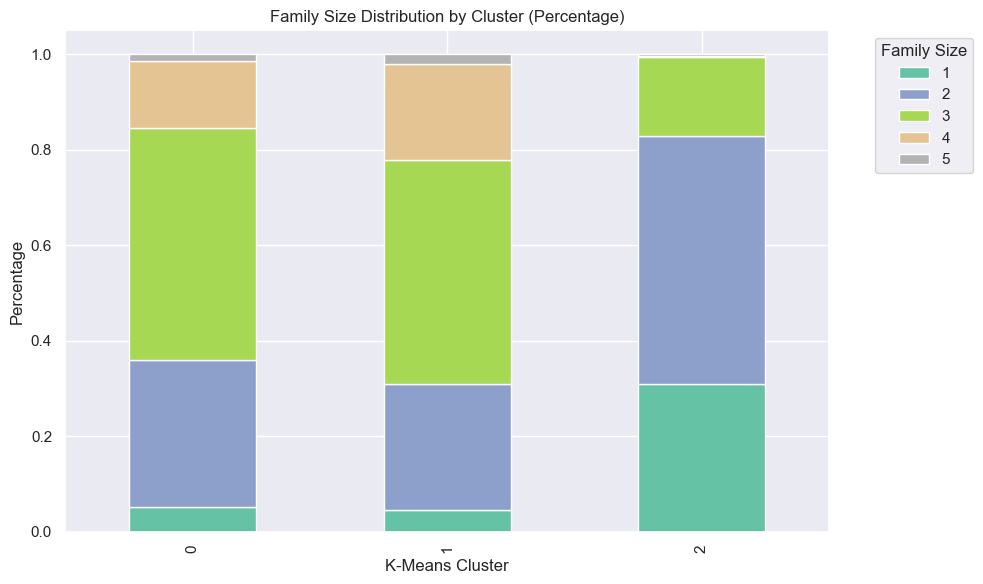

In [64]:
marital_counts = pd.crosstab(df_included_km['KM_segments'], df_included_km['Family_Size'])
marital_pct = marital_counts.div(marital_counts.sum(axis=1), axis=0)

# Step 3: Plot as a stacked bar chart
marital_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
plt.title('Family Size Distribution by Cluster (Percentage)')
plt.xlabel('K-Means Cluster')
plt.ylabel('Percentage')
plt.legend(title='Family Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

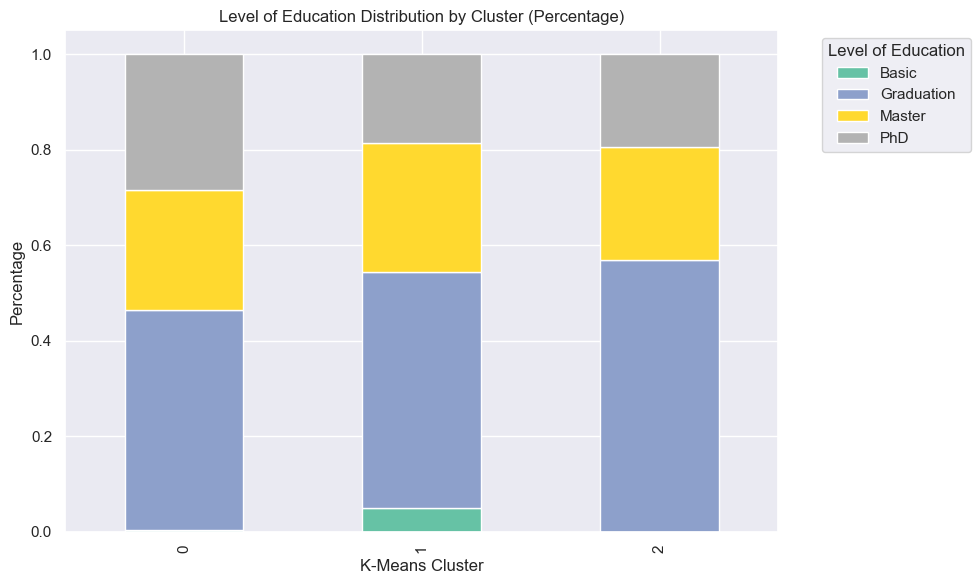

In [65]:
marital_counts = pd.crosstab(df_included_km['KM_segments'], df_included_km['Education'])
marital_pct = marital_counts.div(marital_counts.sum(axis=1), axis=0)

# Step 3: Plot as a stacked bar chart
marital_pct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10,6))
plt.title('Level of Education Distribution by Cluster (Percentage)')
plt.xlabel('K-Means Cluster')
plt.ylabel('Percentage')
plt.legend(title='Level of Education', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observations and Insights:**

- We oberve three groups in K-Mean model.
- **Group0:**
    - Has the lowest count for customers in this group
    - This group used the most deals.
    - They had high purchases throug website. 
    - They have medium average in income and medium average of children.
    - They have highest number of total purchase average. 
    - They have the highest average of age
    - There is the highest number of PdD in this group (mostly educated)
- **Group1:**
    - There is the highest number of customers in this group. 
    - They have the highest average of children. 
    - They have the lowest amount of income.
    - There are some customers with lowest level of education in this group
- **Group2:**
    - They have the highest amount of income average. 
    - They have the highest average in purchasing products (They buy more products)
    - In general they spend more money for shopping. 
    - They usually shop through catalog or inside store. 
    - They have the most engagement with the campaigns.
    - They are mostly two persons or single

## **UMAP** 
- Extra model further study

In [66]:
# Crating umap model with 2 components
reducer = umap.UMAP(random_state=1, n_components=8)
umap_data = reducer.fit_transform(df_scaled)

In [67]:
umap_df = pd.DataFrame(umap_data, columns=[f"UMAP_{i+1}" for i in range(umap_data.shape[1])])

In [68]:
# Using K-Means to cluster on the UMAP data
kmeans_umap = KMeans(n_clusters=3, random_state=1, n_init="auto")
kmeans_umap.fit(umap_df)
score_umap = silhouette_score(umap_df, kmeans_umap.labels_)
print(f"Silhouette Score for K-Means with UMAP data: {score_umap:.4f}")

Silhouette Score for K-Means with UMAP data: 0.4373


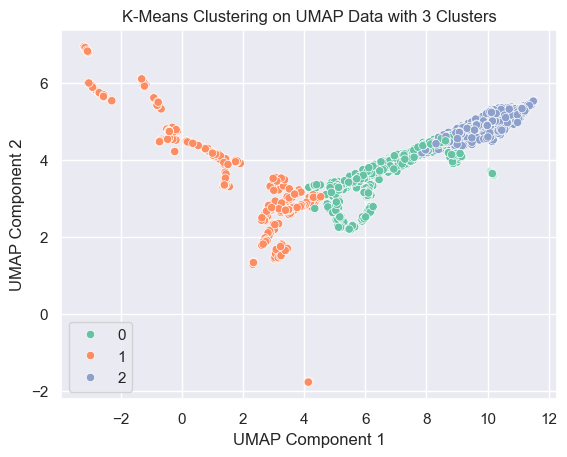

In [69]:
# Visualizing the UMAP clusters to see observabality of the model
sns.scatterplot(x=umap_df["UMAP_1"],
    y=umap_df["UMAP_2"],
    hue=kmeans_umap.labels_,
    palette="Set2")

plt.title('K-Means Clustering on UMAP Data with 3 Clusters')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [70]:
df_included_km_umap = df.copy()
umap_df["UMAP_segments"] = kmeans_umap.labels_
df_included_km_umap["UMAP_segments"] = kmeans_umap.labels_
group_counts_umap = umap_df["UMAP_segments"].value_counts()
df_included_km_umap['Count_per_Group'] = df_included_km_umap['UMAP_segments'].map(group_counts_umap)

In [71]:
umap_profile_mean = df_included_km_umap.groupby("UMAP_segments").mean(numeric_only = True)
umap_profile_median = df_included_km_umap.groupby("UMAP_segments").median(numeric_only = True)
umap_cluster_profile = pd.concat([umap_profile_mean, umap_profile_median], axis=0)
umap_cluster_profile.index = ["group_0 mean", "group_1 mean", "group_2 mean", 
                          "group_0 median", "group_1 median", "group_2 median"]
umap_cluster_profile.T.style.highlight_max(color = "lightgreen", axis = 1)

,group_0 mean,group_1 mean,group_2 mean,group_0 median,group_1 median,group_2 median
Income,43803.746642,33495.713124,71524.993399,45006.000000,33264.000000,71854.000000
Recency,47.856442,50.001736,49.793269,48.000000,50.000000,52.000000
MntWines,183.749693,20.774306,619.475962,134.000000,13.000000,572.000000
MntFruits,9.602454,3.295139,58.435096,5.000000,2.000000,44.000000
MntMeatProducts,60.921472,12.482639,371.609375,48.000000,10.000000,322.000000
MntFishProducts,13.925153,4.991319,83.310096,7.000000,3.000000,69.000000
MntSweetProducts,10.098160,3.355903,59.703125,5.000000,1.000000,45.000000
MntGoldProds,36.928834,9.262153,74.867788,24.000000,6.000000,55.000000
NumDealsPurchases,3.451534,1.355903,1.894231,3.000000,1.000000,1.000000
NumWebPurchases,4.455215,1.458333,5.544471,4.000000,1.000000,5.000000


**Observation:**
- The Silhouette score with umap reduction method increases significantly
- Risks:
    - UMAP is non-linear and aggressively reduces dimensions and transforms the data into an abstract representation that is not easily interpretable in terms of original features.
    - UMAP will be slow with larger data
- When to use
    - When the qualiy of the segments is more important than interpretability
    - When the difference is much higher
    - for exploring more and finding hidden data


## **HdDBSCAN**
- In the Milestone project we saw that DBSCAN does not give us any useful clusters (only 2 and most of the data were blonging to -1 which is considered as noise).
- Now we try to improve DBSCAN into HdDBSCAN combined with UMAP reduction method. 

In [72]:
hdb_df = data_pca_sum.copy()

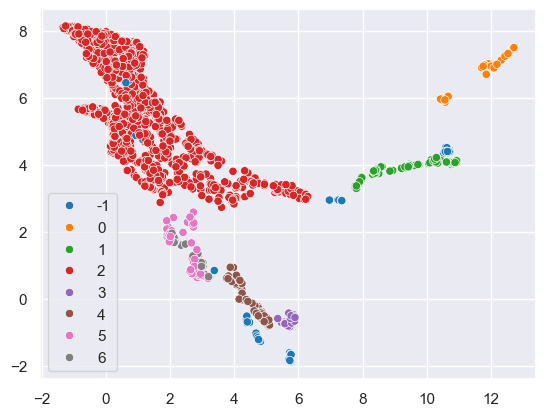

In [73]:
reducer_hdb = umap.UMAP(n_neighbors=15, min_dist=1, n_components=2, random_state=42)
umap_hdb = reducer.fit_transform(hdb_df)

hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=4)
labels = hdb.fit_predict(umap_hdb)


sns.scatterplot(x=umap_hdb[:, 0], y=umap_hdb[:, 1], hue=labels, palette='tab10')
plt.show()

In [74]:
hdb_score = silhouette_score(umap_hdb, labels)
print(f"Silhouette Score for HDBSCAN with UMAP data: {hdb_score:.4f}")

Silhouette Score for HDBSCAN with UMAP data: 0.3249


In [75]:
results =[]
for mcs in [10,20,30,40,50]:
    for ms in [2,3,4,5,10]:
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms)
        labels = hdb.fit_predict(umap_data)
        n_cluster = len(set(labels)) - (1 if -1 in labels else 0)

        mask = labels != -1

        if n_cluster > 2:
            score = silhouette_score(umap_data[mask], labels[mask])
        else:
            score = -1

        print(f"Clusters found with min_cluster_size={mcs} and min_samples={ms}: clusters={n_cluster}, silhouette_score={score:.3f}")
        results.append((mcs, ms, n_cluster, score))
        #sns.scatterplot(x=umap_data[:, 0], y=umap_data[:, 1], hue=labels, palette='tab10')

Clusters found with min_cluster_size=10 and min_samples=2: clusters=85, silhouette_score=0.548
Clusters found with min_cluster_size=10 and min_samples=3: clusters=73, silhouette_score=0.552
Clusters found with min_cluster_size=10 and min_samples=4: clusters=66, silhouette_score=0.590
Clusters found with min_cluster_size=10 and min_samples=5: clusters=67, silhouette_score=0.585
Clusters found with min_cluster_size=10 and min_samples=10: clusters=47, silhouette_score=0.585
Clusters found with min_cluster_size=20 and min_samples=2: clusters=43, silhouette_score=0.489
Clusters found with min_cluster_size=20 and min_samples=3: clusters=34, silhouette_score=0.426
Clusters found with min_cluster_size=20 and min_samples=4: clusters=31, silhouette_score=0.415
Clusters found with min_cluster_size=20 and min_samples=5: clusters=27, silhouette_score=0.395
Clusters found with min_cluster_size=20 and min_samples=10: clusters=15, silhouette_score=0.328
Clusters found with min_cluster_size=30 and min_

**Observation:**
- The clustering is improved compared to the DBSCAN but still so many data are belonging to the noise group
- The Silhouette score is very low
- The higher S. score is related to the higher number of clusters which are detailed too much and cannot be used practically. 
- There are different reasons which make DBSCAN or HDBSCAN fail:
    - Clusters may be tiny, fragmented, or even single-point clusters.
    - The densits of the data could be low. 
    - The data structure might not be well-suited to DBSCAN 

## **Conclusion and Recommendations**

**Comparison of various techniques and their relative performance based on chosen Metric (Measure of success)**:
- After studying two more models, K_mean still remains our best model. 
- Final choosed Model: K_Mean with 3 clusters. S.score = 0.3711


**Insights from the model**:
- Through observing the data based on the chosen model, three different groups were observed:
    - Segment 1: Deal-Driven Digital Shopers
        - **Behavior**
        - This group are the most frequent users of promotional deals.
        - Strong preference for online purchases. 
        - Quite high preference of shopping in store
        - They had the higher average for number of purchases.
        - **Demographics**
        - Medium income and moderate number of children and family size
        - High average of Age (median of 50)
        - Highest number of PhD education (More than 50% educated in Master or PhD)
        - **Campaign Target**
        - This group is highly responsive to discounts
        - They prefer digital channels 
        - Making them ideal for targeted online promotions and deal-based offers

    - Segment 2 : Budget-Concious Families
        - **Behavior**
        - Lower spending level
        - Lower product purchase frequency 
        - Lowest engegement in campaigns
        - They frequenty visit the website
        - **Demographic**
        - Biggest group size
        - lowest income group
        - Highest average number of children and family size
        - **Campaign Target**
        - These are price-sensitive customers 
        - Likely managing larger housholds
        - They may respond better to essentials
        - family-oriented campaigns

    - Segment 3: Engaged Spenders
        - **Behavior**
        - Highest average spend across all purchasing products
        - Spend the most on each purchase
        - Prefering Catalog and in-store shopping over online
        - Most engagement with campaigns
        - **Demographic**
        - Highest average of income
        - Smallest family size mostly with no children (~25% single and ~56% only two person and no family with 2 or more children)
        - Smallest group size
        - **Campaign Target**
        - Premium customers
        - They will be engaged with the campaigns
        - They spend significantly more on each product (specially wine)
        - Ideal for high-end personalized offers and loyalty programs, specially through catalogs and in-store experience




**Problem and Solution Summary**:
- Problem
    - The problem at hand was to perform customer segmentation on a dataset to identify distinct groups of customers based on behavioral and demographic attributes. The objective was to better understand customer profiles and purchase patterns to support targeted marketing strategies. This segmentation aims to enhance marketing efficiency, improve customer engagement, and increase return on investment (ROI) by tailoring communication and offers to specific customer needs.
- Solution
    - Dimensionality Reduction with PCA was applied to reduce noise, remove feature redundancy, and capture the most important patterns in the data while lowering computational complexity.

    - K-Means Clustering was then used to group customers into three distinct segments (k = 3). The choice of k was based on elbow method and silhouette analysis, resulting in a silhouette score of 0.3711, which suggests a moderate structure in the data.

    - This design was selected to capture both purchasing behavior and socio-demographic diversity—critical elements that influence customer segmentation and marketing personalization.
- Impact on the Business
    - Improved Targeting: With clearly defined segments (e.g., high-income engaged shoppers, deal-driven online buyers, and budget-conscious families), marketing teams can tailor campaigns more effectively.

    - Higher ROI: Personalizing communication and offers based on customer segment increases engagement, conversion rates, and ultimately revenue.

    - Better Resource Allocation: Helps prioritize marketing resources toward high-value or high-potential segments.

    - Data-Driven Strategy: Enables evidence-based decision-making rooted in actual customer behavior patterns rather than assumptions.
    

**Recommendations for Implementation**:

1. Key Recommendations to Implement the Solution
    - Integrate Segmentation into CRM and Marketing Tools: Use the cluster labels as features in CRM platforms to enable targeted campaign design and delivery.

    - Personalize Marketing Strategies per Segment:

        - Segment 1 (Deal-Driven Digital Shoppers): Push time-sensitive online deals and personalized promotions.

        - Segment 2 (Budget-Conscious Families): Promote value-for-money products and family bundles.

        - Segment 3 (High-Engaged Spenders): Offer exclusive loyalty programs, premium experiences, and in-store events.

    - Use Segments for Product Development & Campaign Planning: Align future product/service development with segment needs and design campaign content suited to each group.

    - Periodic Re-Clustering: Re-run segmentation quarterly or bi-annually to account for changing behaviors and maintain relevance.

    - Monitor KPIs: Track campaign conversion rates, segment-level revenue, and engagement to assess effectiveness and refine strategies.

2. Key Actionables for Stakeholders
    - Marketing Team:

        - Redesign campaigns to match each segment profile.

        - Allocate budget based on segment value (e.g., more budget to high-value Segment 3).

    - Data & Analytics Team:

        - Maintain the segmentation pipeline (data prep, PCA, clustering).

        - Implement dashboards to visualize segment performance over time.

    - Sales and Customer Support:

        - Train staff to recognize and respond to different customer segment needs.

    - IT/Engineering:

        - Deploy automated workflows to assign new customers to the closest segment using the trained model.
        - Monitoring the channels 

3. Benefits and Costs
- Benefits:

    - Increased Revenue: Targeted campaigns improve conversion rates.
    - Assumption: If each 1% increase in targeting accuracy leads to a 0.5% increase in revenue, and current revenue is $1M/month, even a 5% increase = $25,000/month.

    - Improved Customer Engagement: Personalized content raises email open and click rates.
    Example: Segmented email campaigns can yield 2x–3x engagement.

    - Marketing Cost Efficiency: Avoid wasteful spend on untargeted campaigns; redirect resources to high-performing segments.

- Costs:

    - Initial Setup: $5K–$20K depending on tools and team size for modeling, integration, and testing.

    - Ongoing Maintenance: $1K–$2K/month for model monitoring, retraining, and data processing.

    - Training and Onboarding: Small investment in upskilling marketing and sales teams on segmentation usage.

4. Key Risks and Challenges
- Model Drift: Customer behavior may evolve; segments can become outdated without periodic retraining.

- Over-segmentation or Misclassification: Poor clustering due to noisy data, wrong assumptions, or incorrect k-value can lead to ineffective targeting.

- Data Privacy Concerns: Using sensitive customer data for segmentation must comply with GDPR or other data protection laws.

- Resistance to Adoption: Marketing teams may be slow to adopt data-driven strategies unless results are clearly demonstrated.

5. Further Analysis and Associated Problems to Solve
- Explore Alternative Clustering Models: Exploring the UMAP method deeper to find hidden patterns. Maybe using Bisercting k-mean (Hierarchial + K-Mean) or Fuzzy C-Mean (soft clustering to multiple segments with probabilities).

- Optimizing the behavior twards outliers 

- A/B Test Segment-Specific Campaigns: Validate effectiveness of targeting with controlled experiments.

- Include More Behavioral Features: Consider monetary (RFM) metrics, social media engagement, or customer lifetime value (CLV).

- Incorporate Temporal Dynamics: Study how customer behavior changes over time and segment based on trajectory (dynamic segmentation).